# Show grader function results

This notebook loads a grader YAML file, reads a student notebook submission, extracts the `path_finding` function, evaluates it against every generated terrain, and plots the resulting path in 2D.


In [1]:
CONFIGURATION_FILE = "IA_practica_0.yaml"
SUBMISSION_FILE = "IA_practica_0_test.ipynb"

In [2]:
import sys
from pathlib import Path

try:
    import sIArena
except ModuleNotFoundError:
    source_path = None
    for candidate in (Path("../src"), Path("src")):
        resolved_candidate = candidate.resolve()
        if resolved_candidate.exists():
            source_path = resolved_candidate
            break
    if source_path is None:
        raise ModuleNotFoundError(
            "Could not import sIArena and no local src path was found."
        )
    sys.path.insert(0, str(source_path))
    import sIArena

from sIArena.grading import GraderTestSuite


def resolve_path(file_name, direct_candidates, prefixed_candidates):
    for candidate in direct_candidates:
        if candidate.exists():
            return candidate
    for prefix in prefixed_candidates:
        candidate = prefix / file_name
        if candidate.exists():
            return candidate
    return direct_candidates[0]


grader_path = resolve_path(
    CONFIGURATION_FILE,
    direct_candidates=[Path(CONFIGURATION_FILE)],
    prefixed_candidates=[Path("resources/graders"), Path("graders")],
)

submission_path = resolve_path(
    SUBMISSION_FILE,
    direct_candidates=[Path(SUBMISSION_FILE)],
    prefixed_candidates=[Path("resources/exercises"), Path("exercises")],
)

suite = GraderTestSuite.from_yaml(grader_path)
notebook_result = suite.evaluate_notebook(submission_path)

print(f"Grader file: {grader_path}")
print(f"Submission file: {submission_path}")
print(f"Assignment: {suite.config.assignment.id}")
print(f"Prepared terrains: {len(suite.terrain_cases)}")
print(f"Author: {notebook_result.submission.author}")
print(f"Function cell index: {notebook_result.submission.cell_index}")


Grader file: graders/IA_practica_0.yaml
Submission file: exercises/IA_practica_0_test.ipynb
Assignment: IA_practica_0
Prepared terrains: 20
Author: IA_practica_0_test
Function cell index: 8


In [3]:
if notebook_result.function_result is None:
    print(f"ERROR {notebook_result.load_error_type}: {notebook_result.load_error_message}")
else:
    print(notebook_result.submission.source_code)


from sIArena.terrain.Terrain import Coordinate, Terrain, Path

# Path finding algorithm
def path_finding(terrain: Terrain) -> Path:
    path = [terrain.origin]

    while path[-1] != terrain.destination:
        current = path[-1]
        if current[0] < terrain.destination[0]:
            path.append((current[0] + 1, current[1]))
        elif current[0] > terrain.destination[0]:
            path.append((current[0] - 1, current[1]))
        elif current[1] < terrain.destination[1]:
            path.append((current[0], current[1] + 1))
        elif current[1] > terrain.destination[1]:
            path.append((current[0], current[1] - 1))
    return path



In [4]:
if notebook_result.function_result is None:
    print(f"Notebook could not be evaluated: {notebook_result.comments}")
else:
    evaluation = notebook_result.function_result
    for case_result in evaluation.case_results:
        if case_result.success:
            print(
                f"{case_result.terrain_case.label}: "
                f"time={case_result.elapsed_seconds:.4f}s, "
                f"cost={case_result.path_cost}, "
                f"oracle={case_result.oracle_cost}, "
                f"optimal={case_result.optimal}"
            )
        else:
            print(
                f"{case_result.terrain_case.label}: "
                f"ERROR {case_result.error_type}: {case_result.error_message}"
            )
    if evaluation.comments:
        print(f"COMMENTS: {evaluation.comments}")


trivial[seed=43]: time=0.0003s, cost=8, oracle=8, optimal=True
trivial[seed=44]: time=0.0001s, cost=8, oracle=8, optimal=True
trivial[seed=45]: time=0.0001s, cost=8, oracle=8, optimal=True
trivial[seed=46]: time=0.0001s, cost=8, oracle=8, optimal=True
trivial[seed=47]: time=0.0001s, cost=8, oracle=8, optimal=True
tmaze[seed=43]: time=0.0001s, cost=227, oracle=8, optimal=False
tmaze[seed=44]: time=0.0001s, cost=8, oracle=8, optimal=True
tmaze[seed=45]: time=0.0001s, cost=81, oracle=8, optimal=False
tmaze[seed=46]: time=0.0001s, cost=154, oracle=8, optimal=False
tmaze[seed=47]: time=0.0001s, cost=154, oracle=8, optimal=False
large[seed=43]: time=0.0001s, cost=57, oracle=17, optimal=False
large[seed=44]: time=0.0001s, cost=21, oracle=21, optimal=True
large[seed=45]: time=0.0001s, cost=61, oracle=21, optimal=False
large[seed=46]: time=0.0001s, cost=56, oracle=17, optimal=False
large[seed=47]: time=0.0001s, cost=56, oracle=30, optimal=False
mountain[seed=43]: time=0.0001s, cost=41, oracle=1

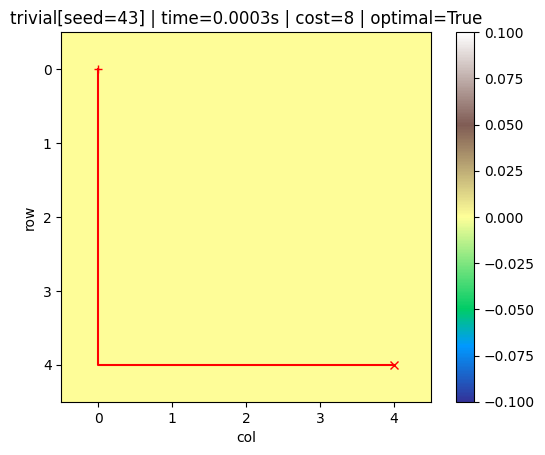

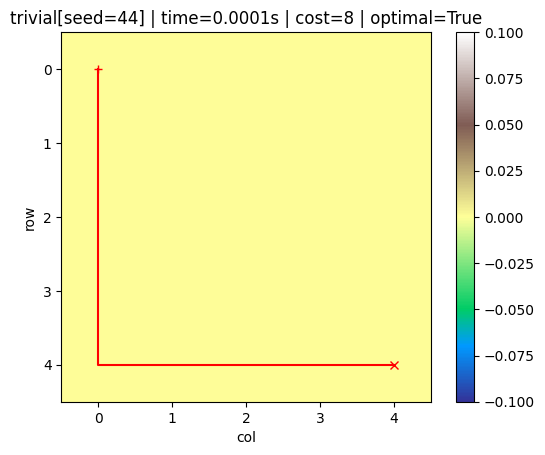

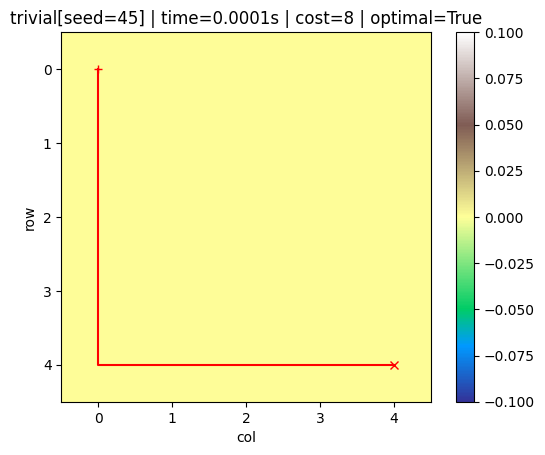

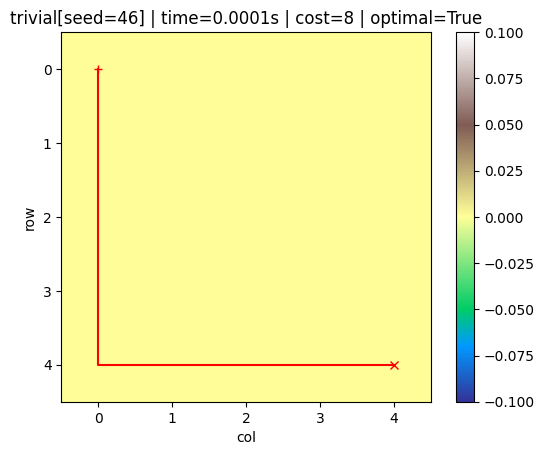

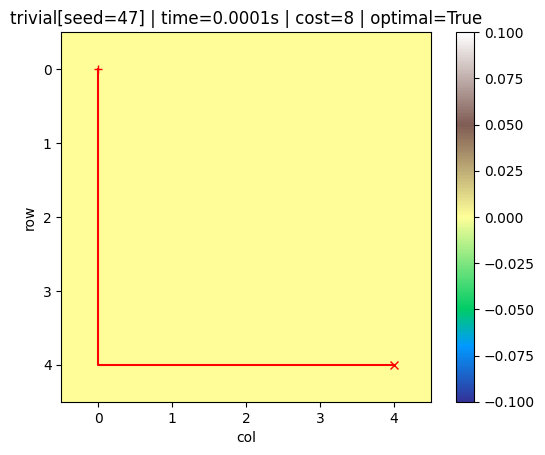

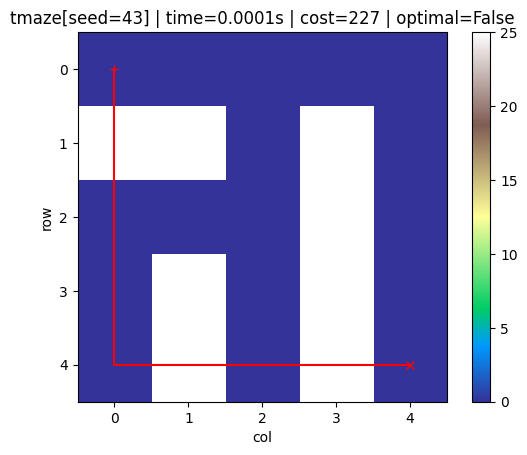

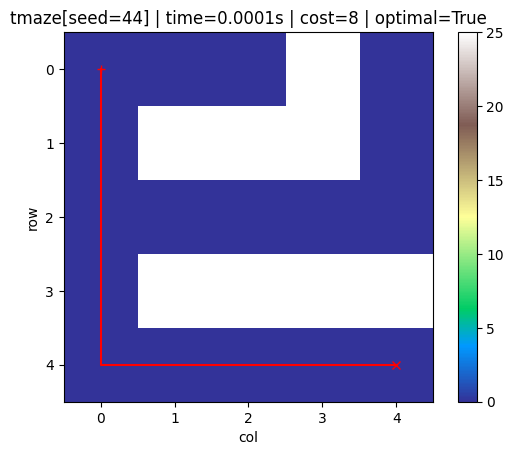

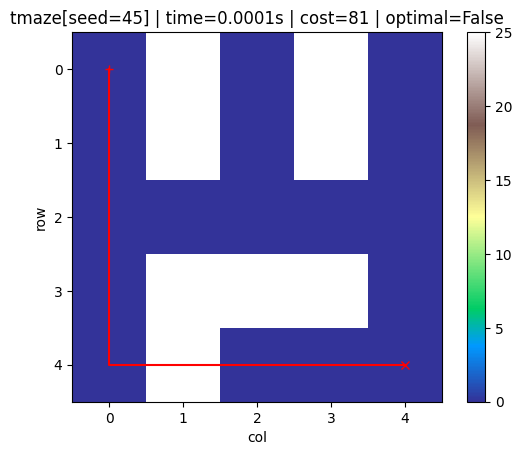

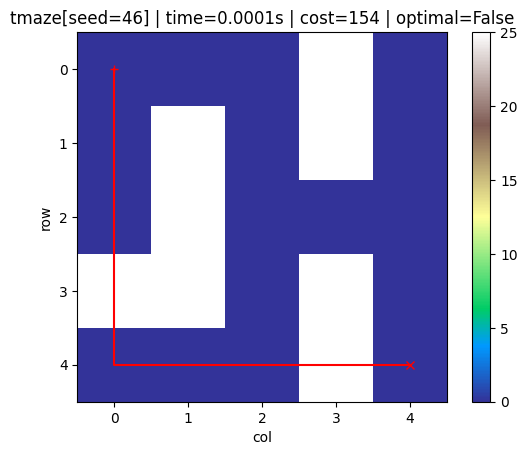

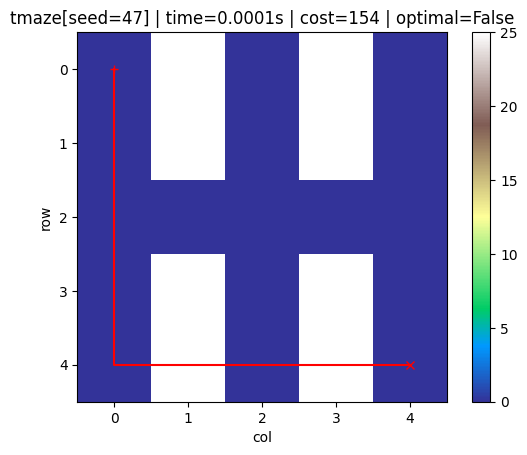

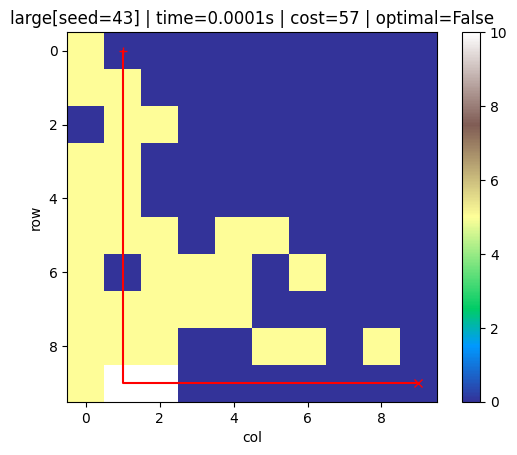

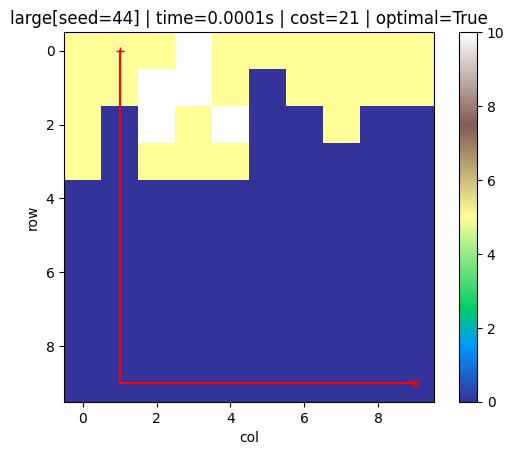

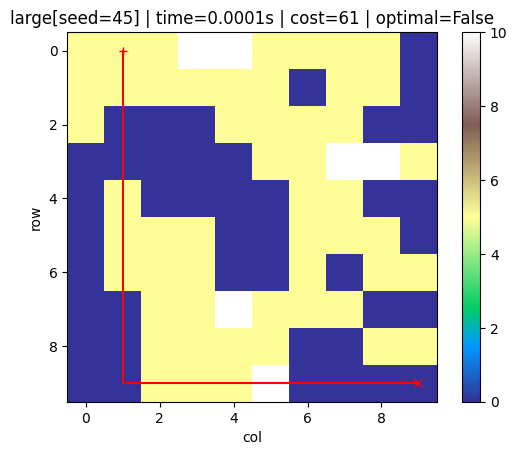

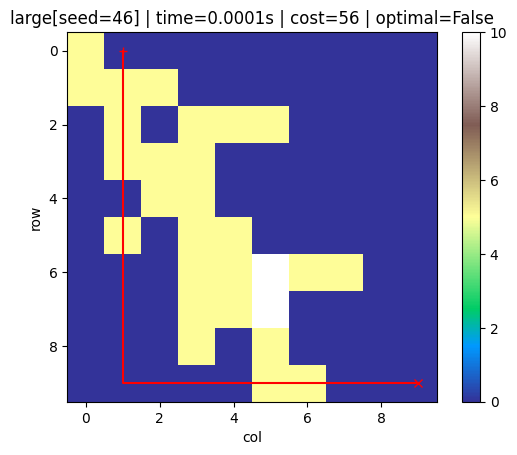

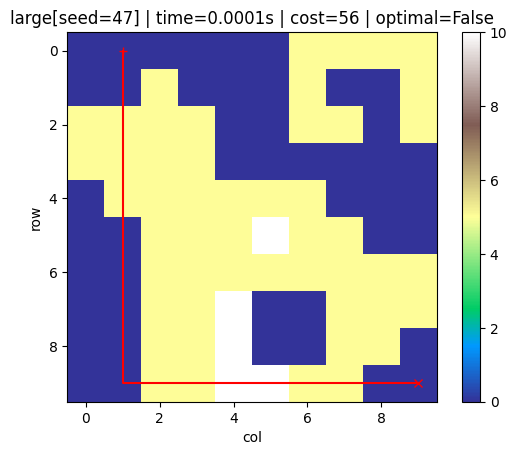

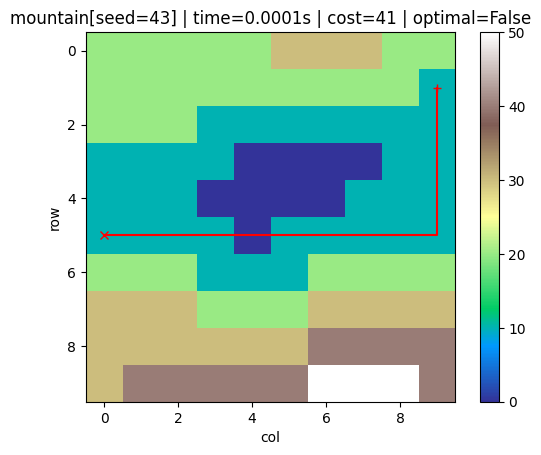

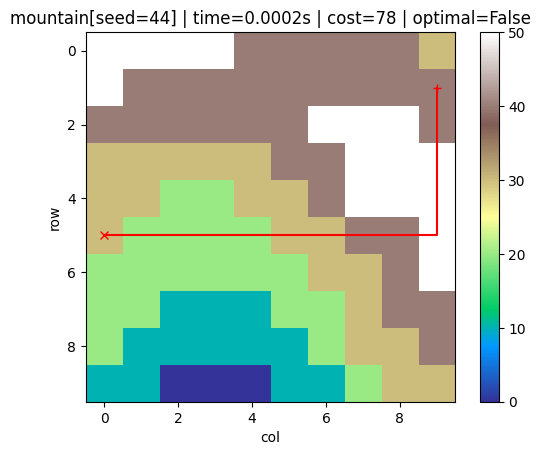

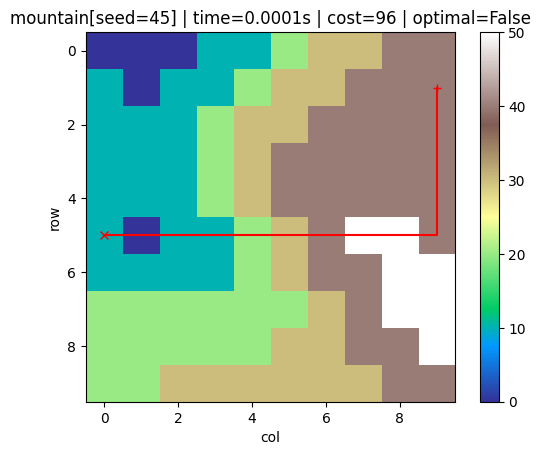

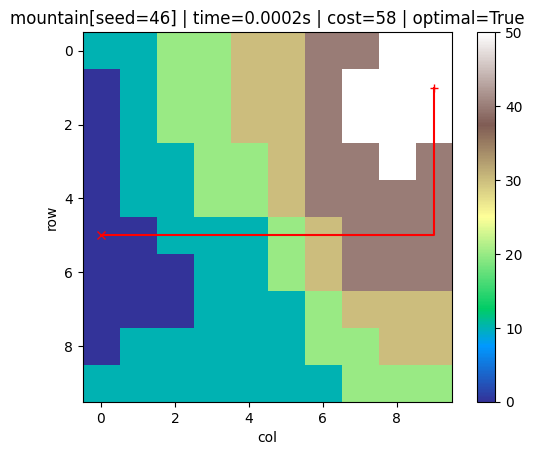

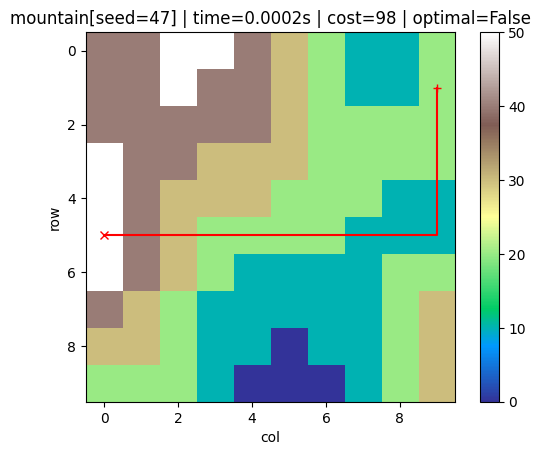

In [5]:
from sIArena.terrain.plot.plot_2D import plot_terrain_2D

if notebook_result.function_result is None:
    print("Plots skipped because the notebook function could not be loaded.")
else:
    for case_result in notebook_result.function_result.case_results:
        title = case_result.terrain_case.label
        if case_result.success:
            title = (
                f"{title} | time={case_result.elapsed_seconds:.4f}s | "
                f"cost={case_result.path_cost} | optimal={case_result.optimal}"
            )
        else:
            title = f"{title} | ERROR: {case_result.error_type}"
        plot_terrain_2D(
            case_result.terrain_case.terrain,
            path=case_result.path,
            title=title,
        )
